In [1]:
import json, chromadb

documents = json.load(open("data/lufthansa_data.json", encoding="utf-8"))   # now 195 clean
texts     = [d["text"] for d in documents]
ids       = [str(i) for i in range(len(documents))]
metadatas = [{"source": d["source"], "url": d["url"]} for d in documents]

client = chromadb.PersistentClient(path="chroma_db")

if any(c.name == "lufthansa" for c in client.list_collections()):
    client.delete_collection("lufthansa")                 # ← clear the OLD 200-doc collection
    
collection = client.get_or_create_collection("lufthansa")
collection.add(documents=texts, metadatas=metadatas, ids=ids)
print("Rebuilt collection:", collection.count())      # should print 195

Rebuilt collection: 341


In [2]:
results = collection.query(
    query_texts=["What are the biggest risks for Lufthansa?"],
    n_results=3 
)

for doc, meta in zip(results["documents"][0], results["metadatas"][0]):
    print(f"[{meta['source']}] {doc[:150]}")
    print(f"    {meta['url']}\n")

[reddit] r/Lufthansa on Reddit: How your first time experience with Lufthansa.
    https://www.reddit.com/r/Lufthansa/comments/1k92jh7/how_your_first_time_experience_with_lufthansa/

[company] Downloads - Lufthansa Group. Annual Report 2025. pdf (7.89 MB) · Financial Statements 2025. pdf (2.05 MB) · Presentation of results 2025. pdf (2.35 MB
    https://report.lufthansagroup.com/2025/annual-report/en/downloads/

[company] Downloads - Lufthansa Group. Documents for the financial year 2024 · Annual Report 2024. pdf (5.86 MB) · Financial Statements 2024. pdf (1.55 MB) · Qu
    https://report.lufthansagroup.com/2024/annual-report/en/downloads/



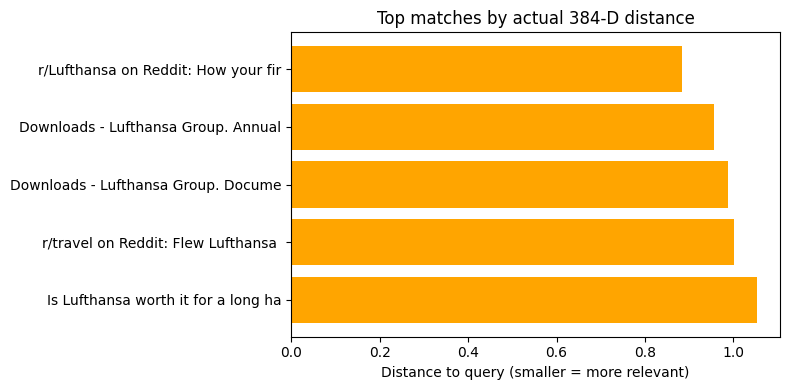

In [3]:
import matplotlib.pyplot as plt

results = collection.query(query_texts=["What are the biggest risks for Lufthansa?"], n_results=5)   # distances returned by default
docs  = [d[:35] for d in results["documents"][0]]
dists = results["distances"][0]

plt.figure(figsize=(8, 4))
plt.barh(docs, dists, color="orange")
plt.xlabel("Distance to query (smaller = more relevant)")
plt.title("Top matches by actual 384-D distance")
plt.gca().invert_yaxis()      # best match on top
plt.tight_layout(); plt.show()


d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\nihal\datacamp\ML practice\ml_env\Lib\site-packages\huggingface_hub\file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


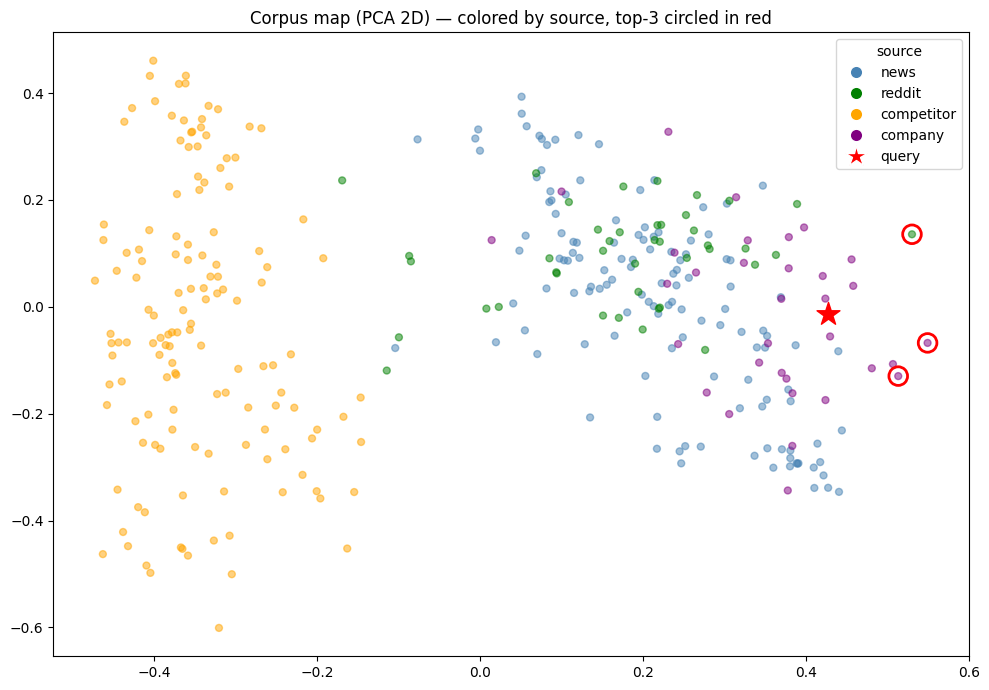

In [4]:
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
from matplotlib.lines import Line2D
import matplotlib.pyplot as plt
import numpy as np

query = "What are the biggest risks for Lufthansa?"

# 1. embed docs + query
model   = SentenceTransformer("all-MiniLM-L6-v2")
doc_emb = model.encode(texts)
q_emb   = model.encode([query])

# 2. squash 384 -> 2
coords = PCA(n_components=2).fit_transform(np.vstack([doc_emb, q_emb]))
doc_xy, q_xy = coords[:-1], coords[-1]

# 3. get the real top-3 from Chroma (ids = positions)
results = collection.query(query_texts=[query], n_results=3)
top_idx = [int(i) for i in results["ids"][0]]

# 4. color each doc by its source (aligned with texts via cleaned_docs)
cmap = {"news": "steelblue", "reddit": "green", "competitor": "orange", "company": "purple"}
pt_colors = [cmap[d["source"]] for d in documents]

# 5. plot
plt.figure(figsize=(10, 7))
plt.scatter(doc_xy[:, 0], doc_xy[:, 1], c=pt_colors, s=25, alpha=0.5)                 # all docs
plt.scatter(doc_xy[top_idx, 0], doc_xy[top_idx, 1], s=180, facecolor="none",          # circle top-3
            edgecolor="red", linewidth=2, zorder=5)
plt.scatter(q_xy[0], q_xy[1], c="red", s=300, marker="*", zorder=6)                   # query

# custom legend (sources + query)
handles = [Line2D([0], [0], marker="o", color="w", markerfacecolor=c, markersize=9, label=s)
           for s, c in cmap.items()]
handles.append(Line2D([0], [0], marker="*", color="w", markerfacecolor="red", markersize=16, label="query"))
plt.legend(handles=handles, title="source")
plt.title("Corpus map (PCA 2D) — colored by source, top-3 circled in red")
plt.tight_layout(); plt.show()

In [5]:
from rank_bm25 import BM25Okapi

# tokenize each document (lowercase + split into words) — BM25 works on word lists
tokenized_corpus = [doc.lower().split() for doc in texts]

bm25 = BM25Okapi(tokenized_corpus)
print("BM25 index built over", len(tokenized_corpus), "docs")

BM25 index built over 341 docs


In [6]:
query = "Lufthansa A350 fleet order"

bm25_scores = bm25.get_scores(query.lower().split())

print(type(bm25_scores))
print(len(bm25_scores))
print(bm25_scores[:10])     # first 10 scores

<class 'numpy.ndarray'>
341
[1.95273886 1.9713815  2.35702202 1.89886815 1.91649173 1.95273886
 1.83150006 1.93444552 1.88156573 1.88156573]


In [7]:
doc_emb = model.encode(texts)      # 200 docs → 200 x 384, takes a few seconds

In [8]:
from sklearn.metrics.pairwise import cosine_similarity

q_emb = model.encode([query])                       # embed the query → 1 x 384
dense_scores = cosine_similarity(q_emb, doc_emb)[0] # compare query to all docs

print(type(dense_scores))
print(len(dense_scores))
print(dense_scores[:10])

<class 'numpy.ndarray'>
341
[0.464947   0.44824952 0.4651808  0.37836975 0.4225064  0.39106324
 0.38625386 0.44578457 0.46330145 0.42714372]


```python
bm25_scores[:5]   -> [1.41, 1.27, 1.67, 1.48, 1.55]   <- keyword, scale ~0 to 2
dense_scores[:5]  -> [0.38, 0.38, 0.32, 0.40, 0.39]   <- meaning, scale ~0 to 0.5
```

If we just added them, BM25's bigger numbers (1.4) would dominate the dense ones (0.4) — keyword would win unfairly. So first we put both on the same 0–1 scale.

In [9]:
import numpy as np

def normalize(x):
    x = np.array(x)
    return (x - x.min()) / (x.max() - x.min())

bm25_norm  = normalize(bm25_scores)
dense_norm = normalize(dense_scores)

print("bm25_norm  range:", bm25_norm.min(), "to", bm25_norm.max())
print("dense_norm range:", dense_norm.min(), "to", dense_norm.max())
print(bm25_norm[:5])
print(dense_norm[:5])

bm25_norm  range: 0.0 to 1.0
dense_norm range: 0.0 to 1.0
[0.18403055 0.18578747 0.22213111 0.17895365 0.18061454]
[0.5551376  0.531981   0.5554619  0.43506947 0.4962796 ]


In [10]:
alpha = 0.5
combined = alpha * dense_norm + (1 - alpha) * bm25_norm

print(combined[:5])

[0.36958406 0.35888423 0.3887965  0.30701156 0.33844707]


```python
alpha = 0.5  →  50% semantic, 50% keyword   (equal trust)
alpha = 0.6  →  60% semantic, 40% keyword   (lean semantic)
alpha = 0.4  →  40% semantic, 60% keyword   (lean keyword)
```

In [11]:
def hybrid_search(query, k=5, alpha=0.5):
    # Step 1 — keyword scores
    bm25_scores  = bm25.get_scores(query.lower().split())

    # Step 2 — semantic scores
    q_emb        = model.encode([query])
    dense_scores = cosine_similarity(q_emb, doc_emb)[0]

    # Step 3 — normalize both, then combine
    bm25_norm  = normalize(bm25_scores)
    dense_norm = normalize(dense_scores)
    combined   = alpha * dense_norm + (1 - alpha) * bm25_norm

    # Step 4 — rank and return top-k
    top_idx = np.argsort(combined)[::-1][:k]
    return [
        {"text": texts[i], "score": round(float(combined[i]), 3),
         "source": documents[i]["source"], "url": documents[i]["url"]}
        for i in top_idx
    ]

In [12]:
for r in hybrid_search("Lufthansa A350 fleet order"):
    print(r["score"], "|", r["source"], "|", r["text"][:80])

0.968 | news | Airbus adds to A350 order book. Jun 1, 2026 . Lufthansa Group has placed a firm 
0.923 | news | Fleet Order - Lufthansa Group. Order and delivery. Lufthansa has ordered a total
0.805 | news | Lufthansa Group orders 10 additional A350-900 | Airbus. May 12, 2026 . Lufthansa
0.774 | news | Lufthansa Fleet Renewal: 10 Airbus A350s And 10 Boeing. The Airbus A350-900 and 
0.74 | news | Lufthansa Group's New $7.5b Aircraft Order | Airbus background. Lufthansa Fleet 
